# Computer Vision - P2

### *Carefully read the following instructions before start coding.*

### **Recommended Preparation**

Before starting P2, it is **recommended that you complete the `p2_tutorial` first**. The tutorial introduces the key concepts and steps needed to complete the practice successfully. Completing it beforehand will help you understand the requirements and avoid common mistakes.


==============================================================================================
## **Practice 2: Image Filtering and Edge Detection**


==============================================================================================

### Main Topics

The main topics covered in this **practical exercise** are:

1. **Image smoothing and convolution** — Exercises 2.1, 2.2, 2.3, and 2.4
2. **Edge detection** — Exercises 2.5, 2.6, and 2.7

To complete this practical exercise, you should understand the following concepts:

* Linear filters
* Histograms
* Convolution
* Image edges

For additional information, refer to the following chapters of *Computer Vision: Algorithms and Applications* by Richard Szeliski:

* **Chapter 3 — Image Processing:** Point Operators and Linear Filtering
* **Chapter 4 — Feature Detection and Matching:** Edges
---

## **2.1 RGB histogram visualization**

**a)** Read the image `./images_notebook/plugs.png` and visualize the **RGB image** and each of its channels (**R, G, and B**) separately. Print the **image shape** and **data type**.

<img src="images_notebook/plugs.png">

> Expected output is illustrated below:

<img src="images_notebook/plugsb.jpg">

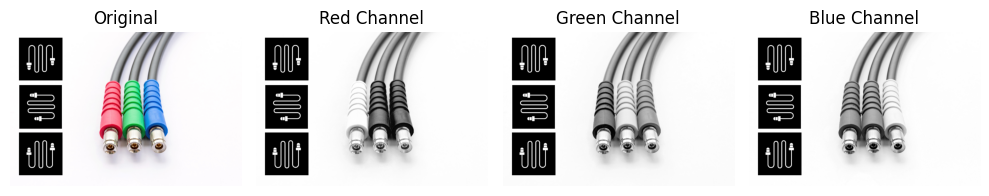

In [146]:
# Import the required libraries.
from skimage import io
from matplotlib import pyplot as plt
import numpy as np
from skimage import img_as_float
from skimage.color import rgb2gray
import matplotlib.image as mpimg

plugs = mpimg.imread("images_notebook/plugs.png")

# Create Figure with 4 Subplots
fig = plt.figure(figsize=(10, 4))
fig.add_subplot(1, 4, 1)
plt.imshow(plugs)
plt.axis("off")
plt.title("Original")
fig.add_subplot(1, 4, 2)
plt.imshow(plugs[:,:,0], cmap='gray')
plt.axis("off")
plt.title("Red Channel")
fig.add_subplot(1, 4, 3)
plt.imshow(plugs[:,:,1], cmap='gray')
plt.axis("off")
plt.title("Green Channel")
fig.add_subplot(1, 4, 4)
plt.imshow(plugs[:,:,2], cmap='gray')
plt.axis("off")
plt.title("Blue Channel")

plt.tight_layout()
plt.show()


**b)** Create a function named `rgb_im_hist(img, nbins=8)` that takes an **RGB image** as input and:

* Displays the **original RGB image**.
* Computes and displays the **histogram of each color channel (R, G, and B)**.
* Converts the image to **grayscale** and displays its histogram.
* Arranges all results **side by side** with appropriate captions.
* Uses `nbins` as an **input parameter** to specify the number of histogram bins. The value of `nbins` can range from **2 to 256**.

> **Note:** Test your function with `nbins = 8, 16, 32, 64, 128,` and `256` to make sure it works correctly for different numbers of histogram bins.

> Expected output is illustrated below (for `nbins=8`):

<img src="images_notebook/rgb_img_hist.jpg">

**Help:** [matplotlib image tutorial](https://matplotlib.org/users/image_tutorial.html)

In [147]:
def rgb_im_hist(img, nbins=8):
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    
    axes[0].imshow(img)
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    r_channel = img[:, :, 0].ravel()
    g_channel = img[:, :, 1].ravel()
    b_channel = img[:, :, 2].ravel()
    
    axes[1].hist(r_channel, bins=nbins)
    axes[1].set_title('Red Channel')
    axes[1].set_xlabel('Intensity')
    axes[1].set_ylabel('Frequency')
    
    axes[2].hist(g_channel, bins=nbins)
    axes[2].set_title('Green Channel')
    axes[2].set_xlabel('Intensity')
    axes[2].set_ylabel('Frequency')
    
    axes[3].hist(b_channel, bins=nbins)
    axes[3].set_title('Blue Channel')
    axes[3].set_xlabel('Intensity')
    axes[3].set_ylabel('Frequency')
    
    gray_img = np.dot(img[...,:3], [0.2989, 0.5870, 0.1140])
    axes[4].hist(gray_img.ravel(), bins=nbins)
    axes[4].set_title('Grayscale')
    axes[4].set_xlabel('Intensity')
    axes[4].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()


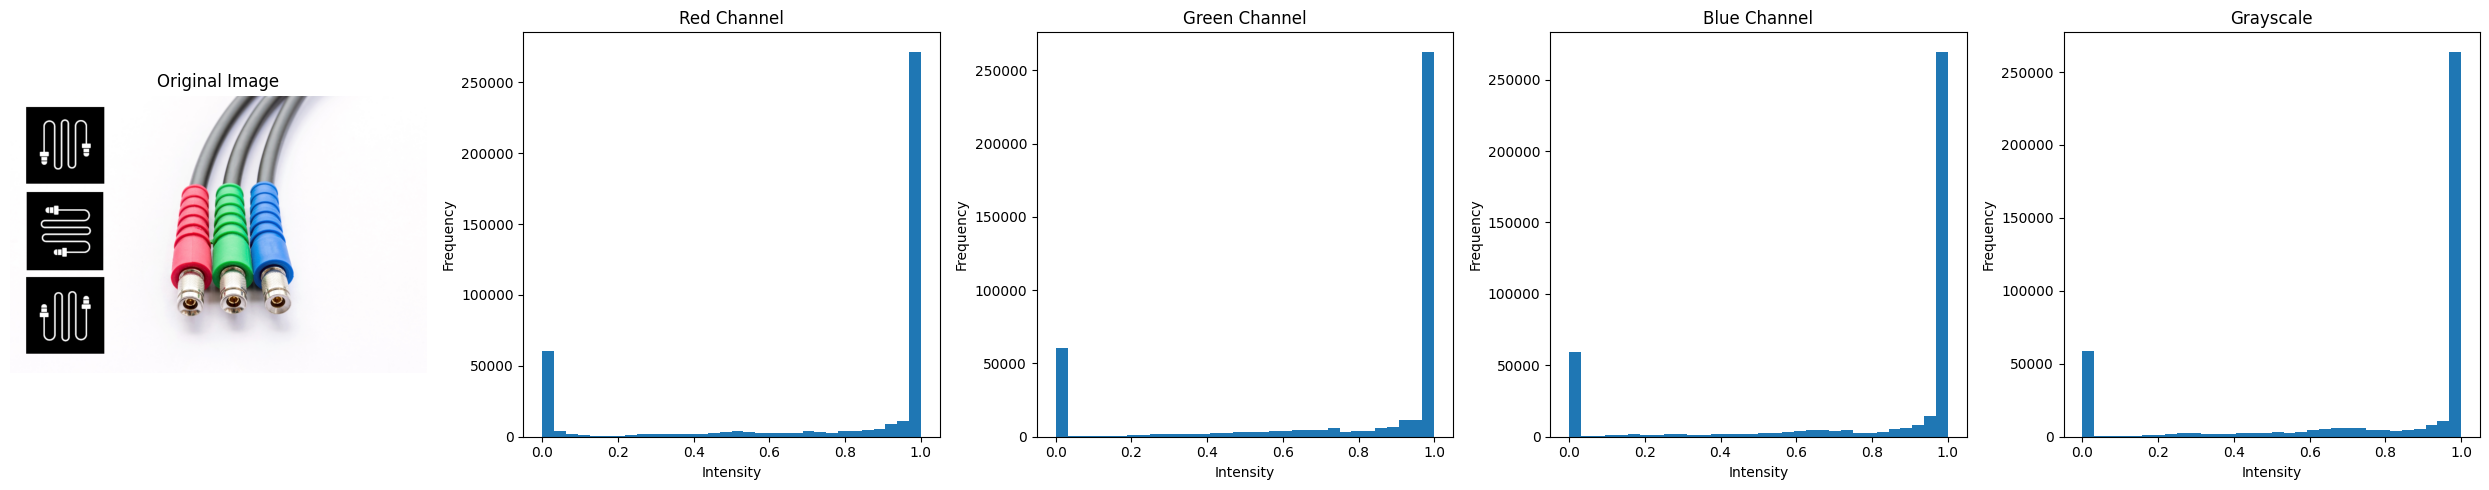

In [148]:
# Call the function with 32 histogram bins.
rgb_im_hist(plugs, nbins=32)

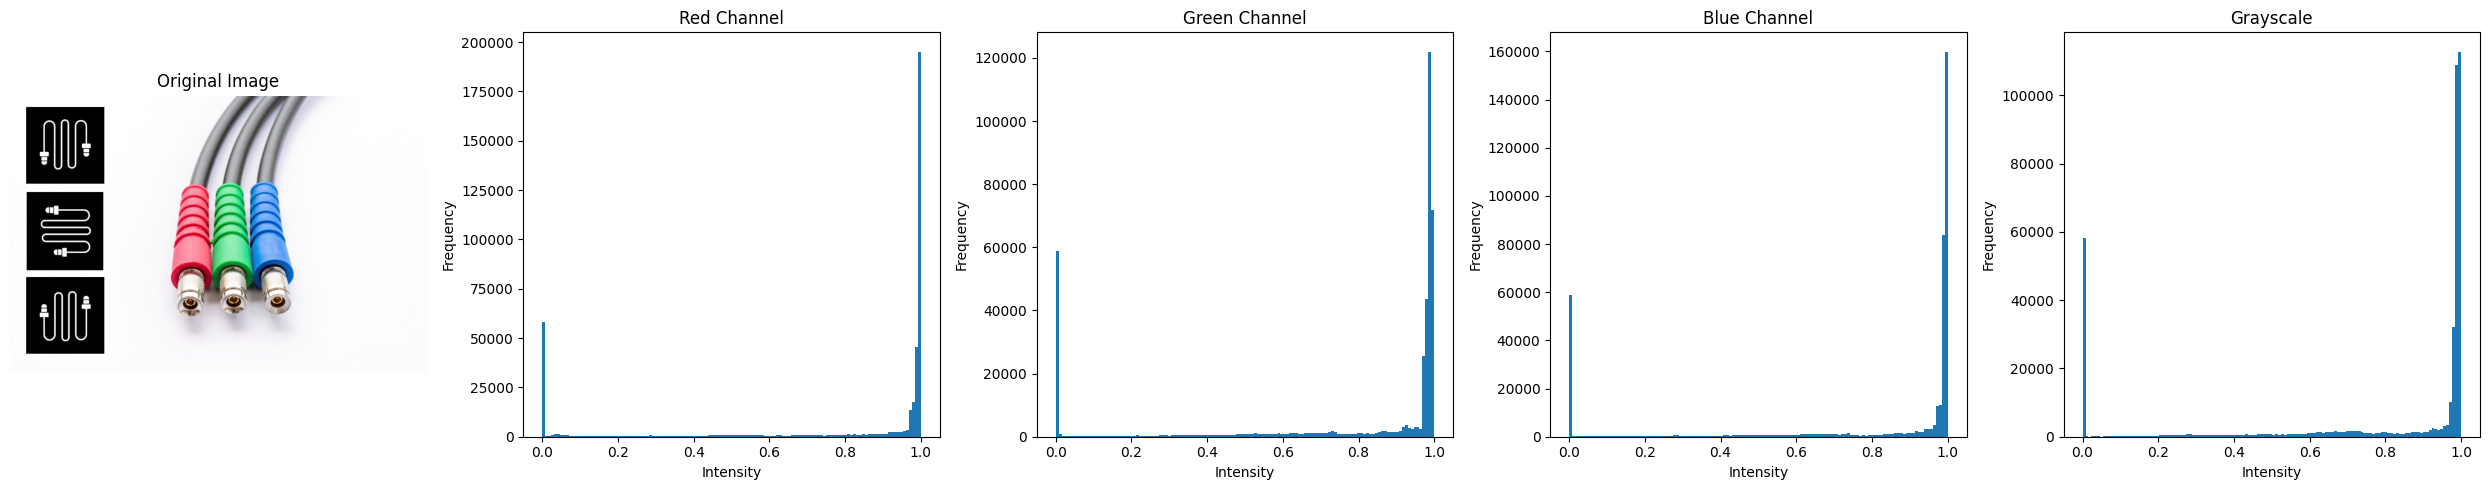

In [149]:
# Call the function with 128 histogram bins.
rgb_im_hist(plugs, nbins=128)

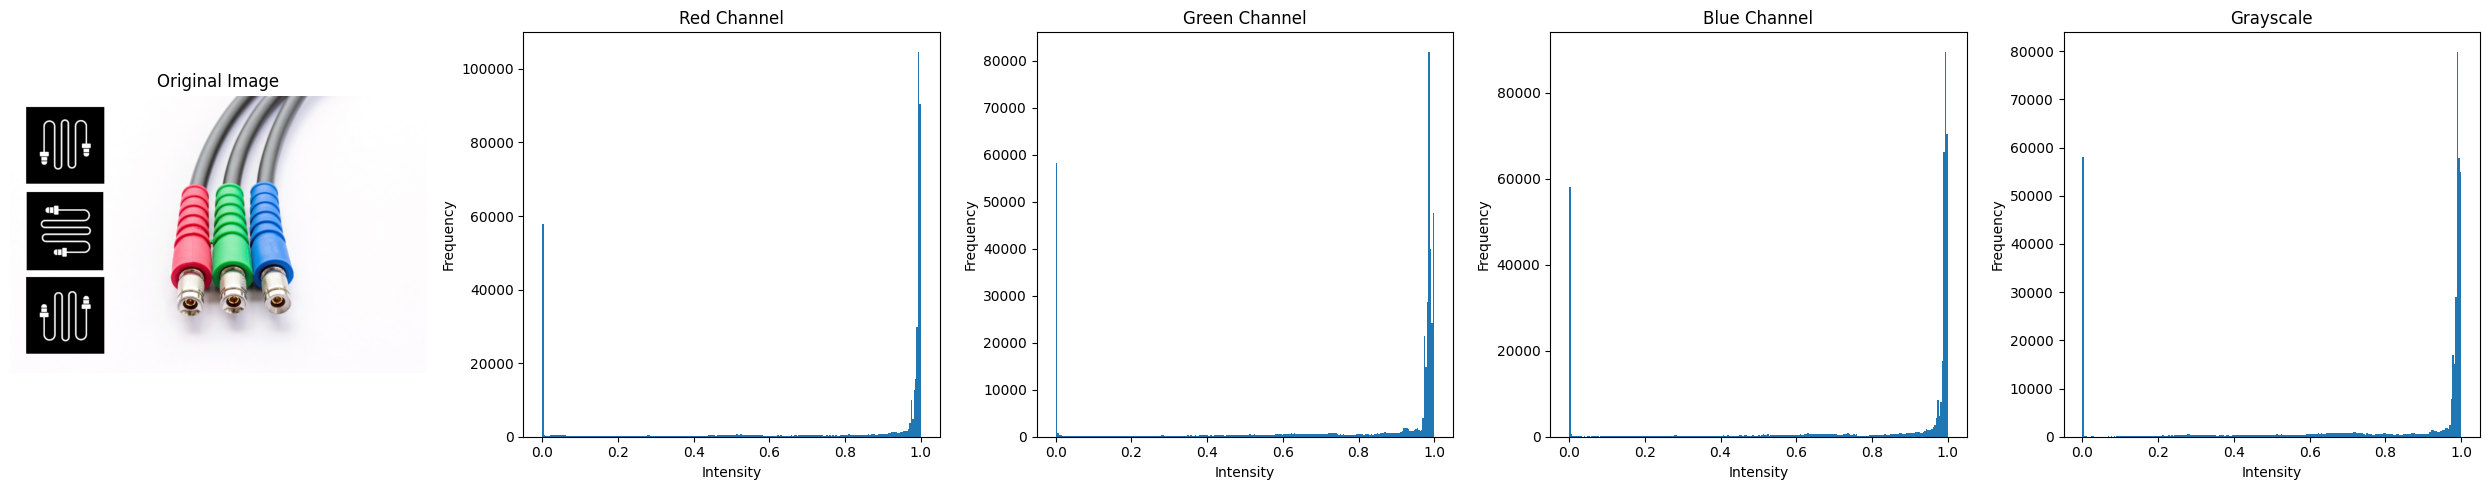

In [150]:
# Call the function with 256 histogram bins.
rgb_im_hist(plugs, nbins=256)

### Discussion

Analyse the plots obtained with different values of `nbins`. In particular, consider:

* How increasing the number of bins affects the **appearance and level of detail** of the histograms.
* The differences between the histograms of the **R, G, and B channels**.
* The relationship between the **RGB channel histograms** and the **grayscale histogram**.
* Which values of `nbins` provide a more useful representation of the image's intensity distribution.
---

## **2.2 Grayscale and RGB images filtering (convolutions)**

**a)** Read the image `./images_notebook/oryx.png`. Resize the image to **256 × 256 pixels** and convert it to grayscale (store the result as `oryx_gray`).

Apply the following convolutions:

1. Convolve `oryx_gray` with the horizontal mask

   `mask_h1d = [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]`

   using the `ndimage.convolve()` function from the `scipy` package.

2. Convolve `oryx_gray` with the transpose of the mask used in part (1).

3. Convolve `oryx_gray` with a uniform **two-dimensional** mask of size **15 × 15**, where all values are equal to 1.

For each resulting image, determine the **minimum value**, **maximum value**, and **data type**.

**Note:** The `convolve()` function performs **multidimensional convolution**. Therefore, a one-dimensional horizontal mask must be represented as `[[1, ..., 1]]`.

**Note:** Before applying `convolve()`, normalize each mask so that the sum of all its elements is equal to 1.


In [151]:
from skimage.transform import resize
from scipy.ndimage import convolve
from scipy import ndimage

# REad the image and resize
oryx = mpimg.imread("images_notebook/oryx.jpg")
oryx_resized = resize(oryx, (256, 256))

# Convert to grayscale
if oryx_resized.ndim >= 3:
    oryx_gray = rgb2gray(oryx_resized[..., :3])
else:
    oryx_gray = oryx_resized

mask_h1d = np.ones((1, 15))
mask_h1d = mask_h1d / np.sum(mask_h1d) # Normalización
conv_h = ndimage.convolve(oryx_gray, mask_h1d)

mask_v1d = mask_h1d.T
conv_v = ndimage.convolve(oryx_gray, mask_v1d)

mask_2d = np.ones((15, 15))
mask_2d = mask_2d / np.sum(mask_2d) # Normalización
conv_2d = ndimage.convolve(oryx_gray, mask_2d)

def print_image_stats(name, img):
    print(f"{name}:")
    print(f"  Min: {img.min():.4f}")
    print(f"  Max: {img.max():.4f}")
    print(f"  Type: {img.dtype}\n")

print_image_stats("Convolución Horizontal", conv_h)
print_image_stats("Convolución Vertical", conv_v)
print_image_stats("Convolución 2D Uniforme", conv_2d)


Convolución Horizontal:
  Min: 0.0794
  Max: 0.7391
  Type: float64

Convolución Vertical:
  Min: 0.0976
  Max: 0.8312
  Type: float64

Convolución 2D Uniforme:
  Min: 0.1612
  Max: 0.6407
  Type: float64



**b)** Visualize the four images—`oryx_gray` and the output of each step from Exercise (a)—in a single figure, using an appropriate title for each image.

Then, consider the following questions:

* Is the data type of the mask important for the convolution operation?
* What effect does each mask have on the original image?
* Compare and discuss the results obtained with the three masks.

**Note:** `matplotlib.pyplot` automatically rescales the image intensity values when displaying an image. Visualize the four images **both with and without intensity-range rescaling** and compare the results.

> Expected output is illustrated below:

<img src="images_notebook/oryx_filtered.jpg">

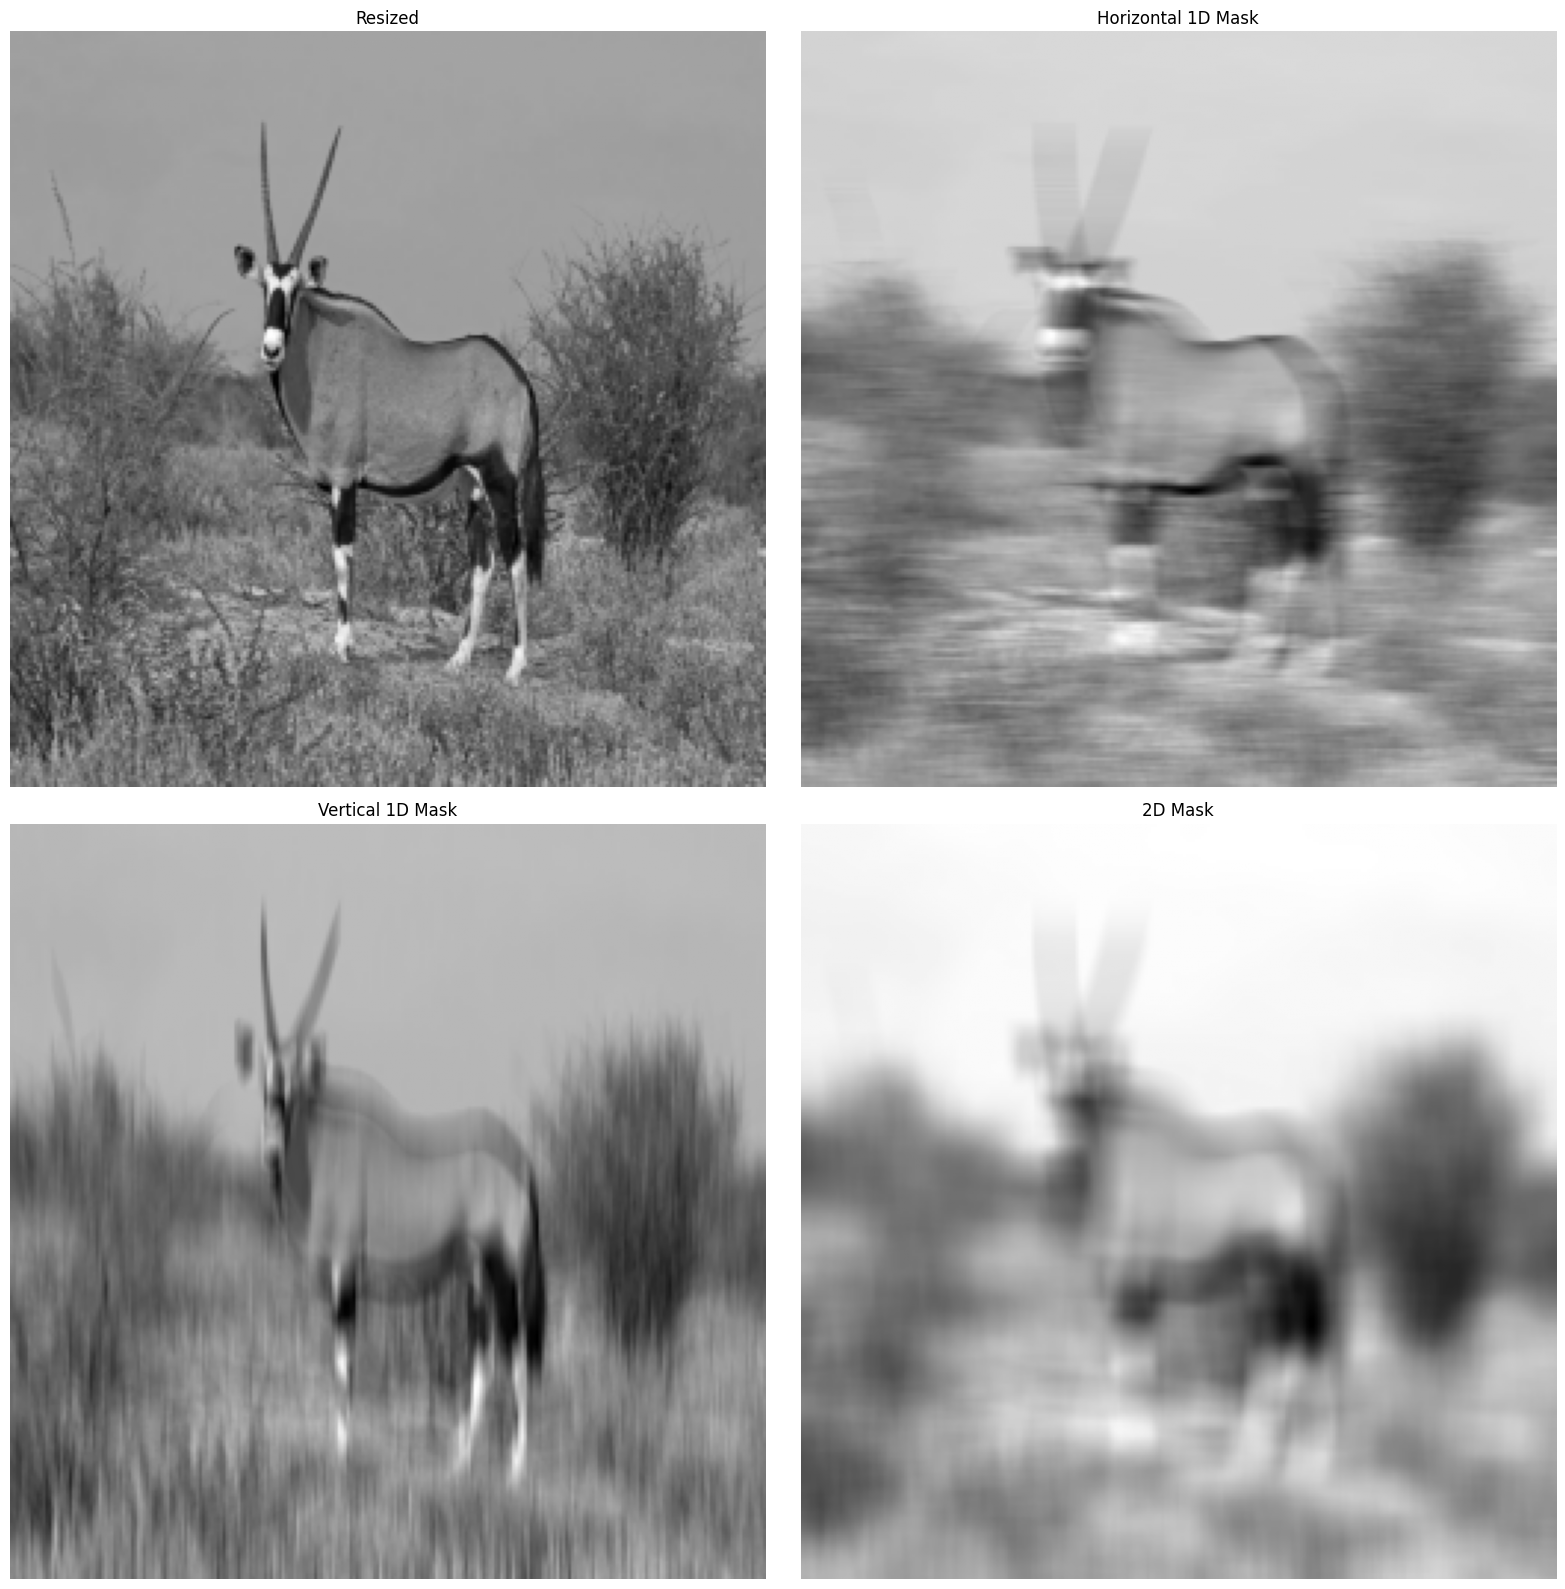

In [152]:
# Create Figure with 4 Subplots
fig = plt.figure(figsize=(16, 16))
fig.add_subplot(2, 2, 1)
plt.imshow(oryx_gray, cmap='gray')
plt.axis("off")
plt.title("Resized")
fig.add_subplot(2, 2, 2)
plt.imshow(conv_h, cmap='gray')
plt.axis("off")
plt.title("Horizontal 1D Mask")
fig.add_subplot(2, 2, 3)
plt.imshow(conv_v, cmap='gray')
plt.axis("off")
plt.title("Vertical 1D Mask")
fig.add_subplot(2, 2, 4)
plt.imshow(conv_2d, cmap='gray')
plt.axis("off")
plt.title("2D Mask")

plt.tight_layout()
plt.show()


### Effect of the Convolution Masks

> **1D Horizontal and Vertical Masks:**
These masks smooth the image in only one direction—horizontally or vertically. This produces directional blurring while preserving more details in the perpendicular direction. As a result, the pixel intensity range is moderately reduced.

> **2D Mask:**
This mask smooths the image in both horizontal and vertical directions simultaneously, producing a stronger overall blurring effect. Because it averages a larger neighborhood of pixels, it generally reduces the pixel intensity range more significantly.


**c) RGB Image Convolution with a 2D Filter**

- Implement a function called `conv_coor(image, mask)` that applies the same 2D filter independently to each of the three RGB channels.

- Resize the original `oryx.png` image to **256 × 256 pixels**, and test your function using a **7 × 7 uniform mask**.

- Visualize the result and compare the filtered RGB image with the original image.

> Expected output is illustrated below:

<img src="images_notebook/rgb_filtered.jpg">


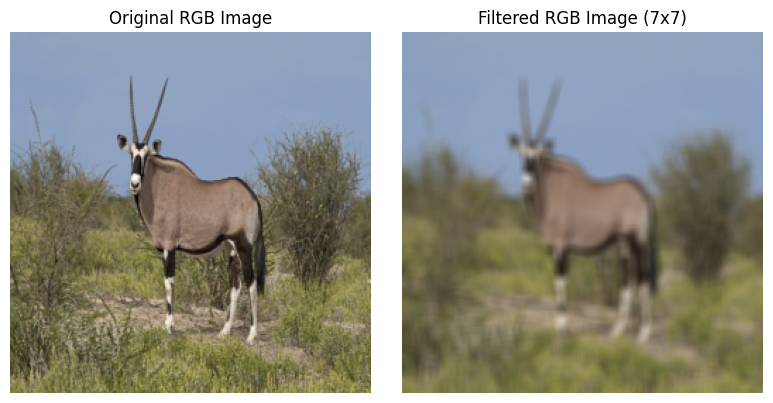

In [153]:
def conv_coor(image, mask):
    r = image[:, :, 0]
    g = image[:, :, 1]
    b = image[:, :, 2]
    
    r_conv = ndimage.convolve(r, mask)
    g_conv = ndimage.convolve(g, mask)
    b_conv = ndimage.convolve(b, mask)
    
    filtered_image = np.dstack((r_conv, g_conv, b_conv))
    return np.clip(filtered_image, 0, 1)

mask_7x7 = np.ones((7, 7))
mask_7x7 = mask_7x7 / np.sum(mask_7x7)

filtered_oryx = conv_coor(oryx_resized, mask_7x7)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(oryx_resized)
axes[0].set_title('Original RGB Image')
axes[0].axis('off')

axes[1].imshow(filtered_oryx)
axes[1].set_title('Filtered RGB Image (7x7)')
axes[1].axis('off')

plt.tight_layout()
plt.show()


## **2.3 Effect of image scale on convolutions**

**a)** Image Rescaling and Histogram Analysis

Resize the grayscale image `oryx_gray` and observe how the image histogram changes.

1. **Reduce** `oryx_gray` by a factor of 20 and compute its histogram using `nbins = 64`.
2. **Enlarge** `oryx_gray` by a factor of 20 and compute its histogram using `nbins = 64`.
3. Display the histograms of the original, reduced, and enlarged images side by side and compare them.

**Question:**
Are there any differences between the histograms? Explain what happens and why the histogram may change after rescaling the image.

> Expected output is illustrated below:

<img src="images_notebook/resize_impact.jpg">


In [154]:
from skimage.transform import rescale

# your solution




**Explanation**

> **Do your analysis here!**

**b) Convolution and Histogram Analysis**

Apply a **7 × 7 uniform convolution mask** to the images from the previous exercise, compute their histograms, and compare the results.

1. **Plot the original `oryx_gray` image and its histogram** for reference.

2. Convolve the original `oryx_gray` image and compute its histogram.

3. Convolve the **reduced `oryx_gray` image from the previous exercise** and compute its histogram.

4. Convolve the **enlarged `oryx_gray` image from the previous exercise** and compute its histogram.

**Note:** Display the images in the **top row** and their corresponding histograms in the **bottom row**, using `nbins = 32`.

**Question:**
Compare the original and filtered images and their histograms. What differences do you observe, and why do these differences occur?

> Expected output is illustrated below:

<img src="images_notebook/oryx_filtered2.jpg">

In [155]:
# your solution




**Explanation**

> **Do your analysis here!**



## **2.4 Image processing with weighting and non-linear filters**

**a) Generate the following kernels and apply them to the `oryx_gray` image:**

1. Generate a Gaussian kernel with σ = 1 and apply it to the image.
2. Generate Gaussian kernels with three different σ values (0.5, 2, and 3) and apply them to the image. Which σ value is the most appropriate for preserving the main objects and structures in the image?
3. Apply a median filter using different mask shapes: disk, rectangle, and diamond. Apply the median filter using different mask sizes for each shape: `disk(5)`, `rectangle(5,20)`, and `diamond(3)`, and compare their effects on the original image. What is the effect of using the different mask shapes on the original image?

> **Note:** For the disk and diamond filters, the specified value represents the **radius in pixels**, while `morphology.rectangle(5, 20)` specifies the **height and width of the rectangular structuring element (5 × 20 pixels)**.


Comment on the effects of the different filters on the original image.

**Hint:** 
- Search for the [skimage.filters function](https://scikit-image.org/docs/stable/api/skimage.filters.html) for creating the different filters.
- Also check [scikit-image — skimage.morphology documentation](https://scikit-image.org/docs/stable/api/skimage.morphology)

> Expected output is illustrated below:

<img src="images_notebook/filter.jpg">


In [156]:
from skimage import filters, img_as_float, morphology
from skimage.filters import gaussian, median
from skimage.morphology import disk, rectangle, diamond
import matplotlib.pyplot as plt

# your solution



### Discussion

> **Do your analysis here!**



b) **(Optional)** Apply the smoothing on some other images and present their results.

In [157]:
#your solution

### **2.5 Comparison of Edge Detection Techniques**

**a)** Load the 'logo_pozo.jpg' image and visualize its contours.

<img src="images_notebook/logo_pozo.jpg" width="200" height="200">

First, convert it to gray scale. Then, apply the different contour extraction tecniques introduced during the theory session and change any parameter if necessary for detecting the edges of the image:

1. Prewitt
2. Sobel
3. Canny

Use subplot and title to visualize the results.

#### **Questions**

* What are the optimal parameter values for each method?
* Is it necessary to normalize the masks, as is commonly done when applying smoothing filters? Explain your answer.

**Hint:** Use `skimage.feature.canny` for the Canny edge detector and `skimage.filters` for the Prewitt and Sobel operators.

> Expected output is illustrated below:

<img src="images_notebook/edge.jpg">


> **Note:** Prewitt and Sobel produce grayscale images because they measure edge strength (gradient magnitude), whereas Canny applies thresholding to generate a binary image containing only the detected edges.



In [158]:
import warnings
warnings.filterwarnings("ignore")
from skimage.feature import canny
from skimage.filters import sobel, prewitt

# your solution



### Discussion

- What are the optimal parameter values for each method?

> **Do your analysis here!**

- Is it necessary to normalize the masks, as is commonly done when applying smoothing filters?

> **Do your analysis here!**

**b)**	Repeat the experiment with other images, you can use the ones included in the folder **images** (`cr.jpg` and `messi.jpg`). 
- Comment if some parameter needs to be changed for the different images.

#### **Questions**

- Does applying smoothing before edge detection improve the detected contours?
- What are the limitations of the different edge detection methods?

In [159]:
#your solution




### Discussion

**1. Does applying smoothing before edge detection improve the detected contours?**

> **Do your analysis here!**

**2. What are the limitations of the different edge detection methods?**

> **Do your analysis here!**

**c)** Implement the Sobel and Prewitt edge detection operators manually using the `convolve` function instead of the implementations provided by `skimage.filters`.

- Define the corresponding horizontal and vertical kernels for each operator, apply them to the image using convolution, and compute the gradient magnitude from the resulting responses.

- Visualize the results and compare them with those obtained using `skimage.filters.sobel` and `skimage.filters.prewitt`.

> Expected output is illustrated below:

<img src="images_notebook/implemented_detectors.jpg">

In [160]:
from skimage.util import img_as_ubyte

#your solution




### 2.6 Applying smoothing in order to obtain hybrid images

**a)** Given `./images_notebook/messi.jpg` and `./images_notebook/cr.jpg` images:

1. Plot both images.
2. Apply a low-pass filter to both of them and plot them.
3. Apply a high-pass filter to both of them and plot them.

The result should be something like:


<img src="images_notebook/Messi.png" height="200">
<img src="images_notebook/CR.png" height="200">


By applying smoothing over an image I, we apply a `low-pass` filter. The resulting image can be called L(I). If we substract the filtered one from the original image, we obtain its high frequencies, that we can call H(I), i.e. we apply a `high-pass` filter.

***H(I) = I - L(I)***

***Hint:*** In order to highlight the effect, in the L(I) image you should define a lower sigma.

In [161]:
# Import the necessary libraries
from skimage import io
from skimage.color import rgb2gray
from skimage.filters import gaussian
from skimage.transform import resize

# your solution



**b)** Create hybrid images and visualize them. A hybrid image is obtained by combining the low and high frequencies of the image, i.e. combining the results obtained by the `low-pass` and `high-pass` filters.

<img src="images_notebook/Fusion.gif" width="400" height="400">

***Hybrid (I1, I2) = L(I1) + H(I2)***



### Exercise: Create Hybrid Images

Using the low- and high-frequency components obtained from the `messi` and `cr` images, create two hybrid images.

1. Create **Hybrid Image 1** by combining the low-frequency component of `cr` with the high-frequency component of `messi`, giving both components equal weight (`0.5`).
2. Create **Hybrid Image 2** by combining the low-frequency component of `messi` with the high-frequency component of `cr`, also giving both components equal weight (`0.5`).
3. Multiply each result by `2` to compensate for the averaging.
4. Display both hybrid images side by side in a `1 × 2` grid, without axes, and with appropriate titles.

> Expected result is shown below:

<img src="images_notebook/Hybrid.png" height="200">


> Hybrid images can be used in **visual illusions, art and design, advertising, visual perception research, and computer vision applications**, where different details are perceived at different viewing distances.


In [162]:
# your solution



## **2.7 Anonimization of sensitive information**

One of the important problems in Computer Vision as a science that manages data (images and videos) is the anonimization of sensitive information appearing in the images.
For example, it is common in applications like Google Street View, where the faces and license plates are anonymized.
The file `./images_notebook/car.png` contains two cars. Anonimize the license plates of the cars using the techniques learned in this practicum.

Modify only the license plates of the cars, keeping the rest of the image unchanged.

Expected result is illustrated below:

<img src="images_notebook/anonimyzed.jpg" height="350">

In [163]:
# your solution



